In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

(35.0, 50.0)

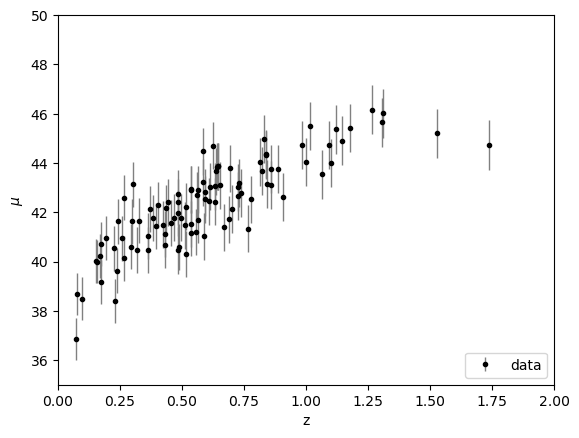

In [3]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [9]:
X = z_sample[:, np.newaxis]
y = mu_sample

In [18]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

X_new = np.array([[min(z_sample)],[max(z_sample)]])
y_pred = theta0+theta1*X_new


39.60456481105869 [4.5911933]


(35.0, 50.0)

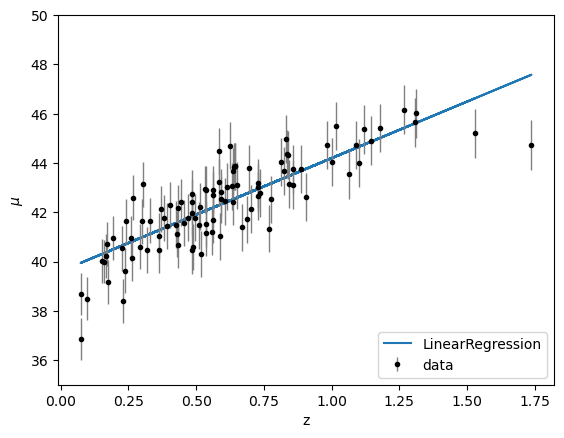

In [19]:
plt.plot(X[:,0],theta0+theta1*X[:,0],label='LinearRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50)

[ 36.09081526  32.02899002 -73.25156852  87.69138092 -47.26697125
   9.15349892]


(35.0, 50.0)

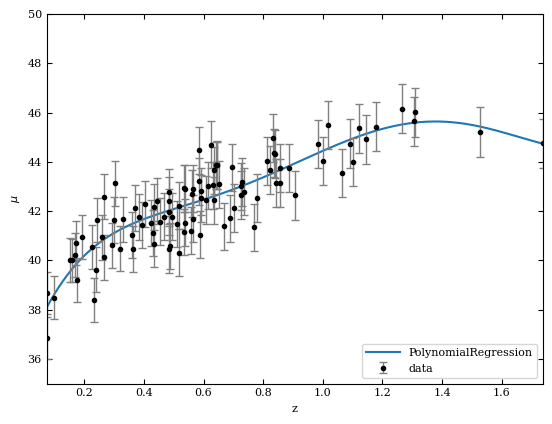

In [57]:
from astroML.linear_model import PolynomialRegression


degree = 5
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50)

/tmp/ipykernel_137844/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_137844/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_137844/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_137844/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])


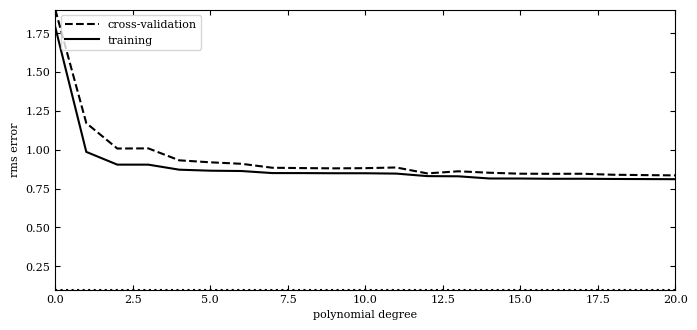

In [70]:
# CROSS VALIDATION

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

x = X[:,0]
dy = dmu

# Select the cross-validation points
np.random.seed(1)
x_cv = z_sample[::3] # I take 1/3 of the sample 
y_cv = mu_sample[::3]

x_fit = np.linspace(min(z_sample),max(z_sample), 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(x, y, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, x) - y) ** 2)
                              / len(y))
    crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2)
                              / len(y_cv))


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')



ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)


plt.show()

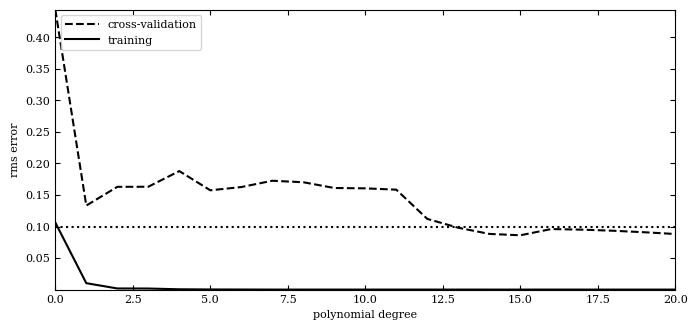

In [71]:
# CROSS VALIDATION

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)



# Select the cross-validation points
np.random.seed(1)
x_cv = z_sample[:30] # I take 1/3 of the sample 
y_cv = mu_sample[:30]

x_fit = np.linspace(min(z_sample),max(z_sample), 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    model = PolynomialRegression(i) # fit 3rd degree polynomial
    model.fit(X[30:], y[30:],y_error=dmu[30:])
    
    y_pred = model.predict(X[30:])
    y_pred_cv = model.predict(X[:30])
    
    training_err[i] = np.sqrt((np.sum(y_pred - y) ** 2))/ len(y)
    crossval_err[i] = np.sqrt(np.sum(y_pred_cv - y_cv) ** 2)/ len(y_cv)


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')



ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)


plt.show()

[20.8016672   3.5091414   3.7469782   3.8019351   4.11376634  4.13199757
  4.36895315  4.47850271  4.80974925  4.31792133  5.21531913]


(35.0, 50.0)

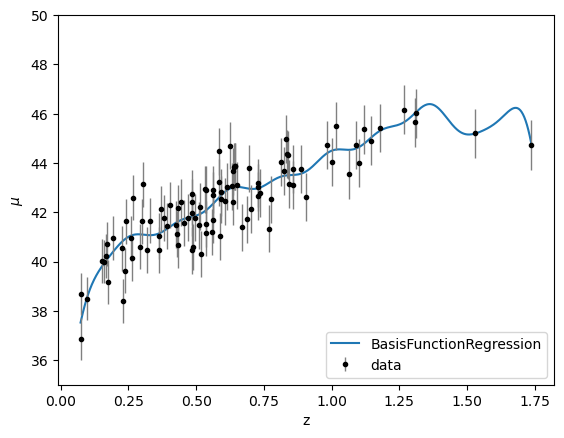

In [49]:
from astroML.linear_model import BasisFunctionRegression

# data

# mean positions of the 10 Gaussians in the model
X_gridtest = np.linspace(min(z_sample),max(z_sample),10)[:, None]
# widths of these Gaussians
sigma_test = 0.1

model = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model.fit(X, y, dmu)

y_pred = model.predict(X_test)
print(model.coef_)

plt.plot(X_test[:,0],y_pred,label='BasisFunctionRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

(35.0, 50.0)

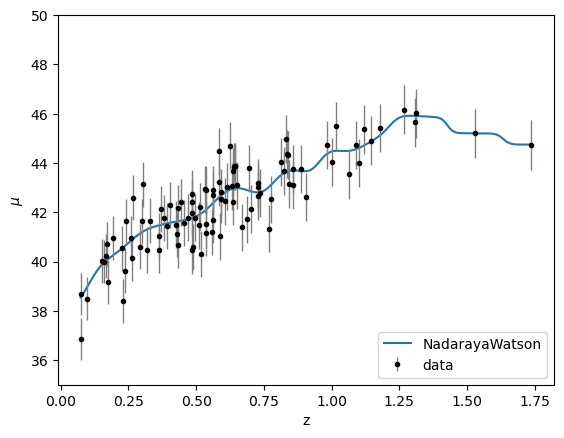

In [51]:
from astroML.linear_model import NadarayaWatson

model = NadarayaWatson(kernel='gaussian', h=0.05)
model.fit(X,y)

y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='NadarayaWatson')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)